# **EmporiUm Sales Territory Analysis**

Paola Martinez  
lana Llana

South Region

-

**First Territory** - Lana Ilana -  Florida, Store IDs 719-729

**Second Territory** - Jeff "Howdy" Richards - Texas, Store IDs 901-911

-

**Description**
EmporiUm is a growing student bookstore chain that also sells tech gear, art supplies, and other
products both in-store and online. A marketing manager has asked you for some analysis comparing sales in the two territories assigned to
you. The marketing manager has asked for a full analysis to be presented in the form of a Jupyter Notebook that walks through each step of the
process and the results that you find, including at least two charts to visualize those results.
The goal of this analysis is to compare performance across the two territories, identify top-performing stores and customers, understand product category trends, and make a marketing recommendation for next quarter.
I analyze in-store sales data for two territories in the South region

Jeff Richards' Texas territory ia the second territory because it is the best comparison to the florida territory as they are both in the South region, and both have 11 stores, as well as similar total sales volume.

# **Importing**

 **pandas** — for loading, cleaning, and analyzing data

 **matplotlib.pyplot** — for creating charts


In [ ]:
import pandas as pd #imports the panda library
import matplotlib.pyplot as plt #imports matplotlib for charts

We load each of the five CSV files provided by using the pd.read_csv function

.info() is used to read, column names, non-null values, and data type of each column

The purpose is to identify issues, like columns that should be numbers but loaded as text, or columns with unexpected missing values.

In [ ]:
#store transaction data for sales
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [ ]:
#store details to view specific locations, managers, and region for each store
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [ ]:
#product catalog. This includes product number, product names, and category/Subcategory IDs
products = pd.read_csv('/content/Products (3).csv')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [ ]:
# Read product categories for CategoryID and category names
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [ ]:
# Read customer/rewards member list
# seperator here is "|", not a coma
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


 .head() is used to read the contents of each table. First 5 rows

In [ ]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [ ]:
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [ ]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [ ]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [ ]:
customer_list.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


# **Cleaned**

Transaction Date column reads as a string dtype

pd.to_datetime() to Convert to datetime type so we can get the month and sort/group by time

Month column is added to analyze by month.
 we add a "Month" column using

  .dt.to_period('M') to avoid having to re-extracting the month every time

# **Filtered**
only analyses two regions

.isin() to match territory managers to their stores.

join that with the sales table so every transaction matches with it's respective territory.

In [ ]:
# Convert Transaction Date from string to datetime so we can analyze by month
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Add a Month column by getting year-month from the date
# to_period('M') gives all months
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

print('Date range in data:', store_sales['Transaction Date'].min(), 'to', store_sales['Transaction Date'].max())
print('Month column sample:', store_sales['Month'].head(3).tolist())

Date range in data: 2022-01-01 00:00:00 to 2025-12-31 00:00:00
Month column sample: [Period('2022-01', 'M'), Period('2022-01', 'M'), Period('2022-01', 'M')]


In [ ]:
# Define our two territory managers
our_managers = ['Lana Ilana', 'Jeff "Howdy" Richards']

# Filter StoreDetail to only the stores in our two territories
our_stores = store_detail[store_detail['Territory Manager'].isin(our_managers)].copy()

print('Stores in our territories:')
print(our_stores[['Store Location', 'State', 'Store ID', 'Territory Manager']].to_string(index=False))

Stores in our territories:
 Store Location   State  Store ID     Territory Manager
 Cape Canaveral Florida       719            Lana Ilana
Fort Lauderdale Florida       720            Lana Ilana
   Jacksonville Florida       721            Lana Ilana
       Key West Florida       722            Lana Ilana
       Lakeland Florida       723            Lana Ilana
          Miami Florida       724            Lana Ilana
         Naples Florida       725            Lana Ilana
        Orlando Florida       726            Lana Ilana
        Sebring Florida       727            Lana Ilana
    Tallahassee Florida       728            Lana Ilana
          Tampa Florida       729            Lana Ilana
      Arlington   Texas       901 Jeff "Howdy" Richards
         Austin   Texas       902 Jeff "Howdy" Richards
        Bacliff   Texas       903 Jeff "Howdy" Richards
        Baytown   Texas       904 Jeff "Howdy" Richards
       Beaumont   Texas       905 Jeff "Howdy" Richards
     Cedar Park   Tex

In [ ]:
# Get the list of Store IDs for our territories
our_store_ids = our_stores['Store ID'].tolist()

# Filter StoreSales to only transactions from our stores
our_sales = store_sales[store_sales['Store ID'].isin(our_store_ids)].copy()

print(f'Total transactions in our two territories: {len(our_sales):,}')

Total transactions in our two territories: 52,828


In [ ]:
# Merge territory manager info into our sales table
# This adds the Territory Manager column to every transaction row
# We only bring in the columns we need from StoreDetail
our_sales = our_sales.merge(
    store_detail[['Store ID', 'Territory Manager', 'Store Location', 'State']],
    on='Store ID',
    how='left'
)

our_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Territory Manager,Store Location,State
0,2022-01-01,719,NaN,105376-M,44.50,2022-01,Lana Ilana,Cape Canaveral,Florida
1,2022-01-01,721,NaN,105310-IT,71.74,2022-01,Lana Ilana,Jacksonville,Florida
2,2022-01-01,723,NaN,105377-A,5.00,2022-01,Lana Ilana,Lakeland,Florida
3,2022-01-01,723,NaN,105378-T,155.60,2022-01,Lana Ilana,Lakeland,Florida
4,2022-01-01,724,NaN,105379-A,28.00,2022-01,Lana Ilana,Miami,Florida


# **Core Marketing Analysis**

#6 part 1: Managers, Store IDs, and Cities for territories assigned


In [ ]:
# Display stores grouped by territory manager
for manager, group in our_stores.groupby('Territory Manager'):
    print(f'Territory Manager: {manager}')
    print(f'Region: {group["Region"].iloc[0]}')
    print(group[['Store ID', 'Store Location', 'State']].to_string(index=False))
    print()

Territory Manager: Jeff "Howdy" Richards
Region: South
 Store ID Store Location State
      901      Arlington Texas
      902         Austin Texas
      903        Bacliff Texas
      904        Baytown Texas
      905       Beaumont Texas
      906     Cedar Park Texas
      907         Dallas Texas
      908         Denton Texas
      909         Desoto Texas
      910     Fort Worth Texas
      911     Georgetown Texas

Territory Manager: Lana Ilana
Region: South
 Store ID  Store Location   State
      719  Cape Canaveral Florida
      720 Fort Lauderdale Florida
      721    Jacksonville Florida
      722        Key West Florida
      723        Lakeland Florida
      724           Miami Florida
      725          Naples Florida
      726         Orlando Florida
      727         Sebring Florida
      728     Tallahassee Florida
      729           Tampa Florida



# 6 part 2: Monthly total revenue for in-store sales by territory

.groupby() to group transactions by Month and Territory Manager

Sale Amount for sum of sales for each territory by month

pivot the output so each territory is its own column so it easier to read and translate to a chart

In [ ]:
# Group by Month and Territory Manager, summing Sale Amount
monthly_revenue = (
    our_sales
    .groupby(['Month', 'Territory Manager'])['Sale Amount']
    .sum()
    .reset_index()
)

# Pivot so each territory manager is a column
monthly_pivot = monthly_revenue.pivot(index='Month', columns='Territory Manager', values='Sale Amount')
monthly_pivot.columns.name = None  # Remove the label 'Territory Manager' from column header

print('Monthly Revenue by Territory:')
print(monthly_pivot.to_string())

Monthly Revenue by Territory:
         Jeff "Howdy" Richards  Lana Ilana
Month                                     
2022-01               40857.20    48143.95
2022-02               52729.22    46257.35
2022-03               49214.95    53541.25
2022-04               55229.25    49505.25
2022-05               49696.98    58326.64
2022-06               45208.26    48683.24
2022-07               48308.66    57545.77
2022-08               49641.33    48656.98
2022-09               47977.04    42839.10
2022-10               50543.10    49508.42
2022-11               41402.48    44519.86
2022-12               49055.84    50885.58
2023-01               72298.63    70589.71
2023-02               45399.37    74547.62
2023-03               67468.76    71490.80
2023-04               76712.34    71671.43
2023-05               74059.48    76942.62
2023-06               68340.04    75958.75
2023-07               63941.07    74438.54
2023-08               60700.57    71626.47
2023-09               69

## 6 part 3: Store Performance Rankings

We group by `Store ID` and sum total revenue for the full data period. We then merge back in the store's city name so the results are human-readable (store IDs alone are not very meaningful). Sorting from highest to lowest gives us the ranking.

In [ ]:
# Total revenue per store across the full period
store_revenue = (
    our_sales
    .groupby(['Store ID', 'Store Location', 'Territory Manager'])['Sale Amount']
    .sum()
    .reset_index()
    .rename(columns={'Sale Amount': 'Total Revenue'})
    .sort_values('Total Revenue', ascending=False)
)

# Add a rank column within each territory
store_revenue['Rank'] = store_revenue.groupby('Territory Manager')['Total Revenue'].rank(
    ascending=False, method='min'
).astype(int)

# Display Lana Ilana's stores
print('--- Lana Ilana (Florida) Store Rankings ---')
lana_stores = store_revenue[store_revenue['Territory Manager'] == 'Lana Ilana'].sort_values('Rank')
print(lana_stores[['Rank', 'Store ID', 'Store Location', 'Total Revenue']].to_string(index=False))

print()

# Display Jeff Richards' stores
print('Jeff Richards (Texas) Store Rankings')
jeff_stores = store_revenue[store_revenue['Territory Manager'] == 'Jeff "Howdy" Richards'].sort_values('Rank')
print(jeff_stores[['Rank', 'Store ID', 'Store Location', 'Total Revenue']].to_string(index=False))

--- Lana Ilana (Florida) Store Rankings ---
 Rank  Store ID  Store Location  Total Revenue
    1       724           Miami      618846.25
    2       728     Tallahassee      541670.66
    3       722        Key West      332620.43
    4       719  Cape Canaveral      331956.13
    5       721    Jacksonville      331667.08
    6       727         Sebring      330848.14
    7       729           Tampa      308979.01
    8       720 Fort Lauderdale      302270.07
    9       726         Orlando      297891.71
   10       723        Lakeland      273835.24
   11       725          Naples      259602.83

Jeff Richards (Texas) Store Rankings
 Rank  Store ID Store Location  Total Revenue
    1       905       Beaumont      637818.90
    2       910     Fort Worth      351772.59
    3       909         Desoto      330720.12
    4       906     Cedar Park      312628.27
    5       904        Baytown      298163.16
    6       908         Denton      298111.45
    7       901      Arlington  

## 6 part 4: Top Customers by Territory

The sales table has a `RewardsID` column that links to the `cust_id` column in the customer list. However, not every transaction has a rewards ID — non-members shop without one, so those rows have `NaN`. We use `.dropna()` to keep only transactions where a rewards ID is present.

We then merge with the customer list to get the customer's name alongside their ID, and sum their total spending.

In [ ]:
# Keep only transactions that have a RewardsID (i.e., the customer is a rewards member)
rewards_sales = our_sales.dropna(subset=['RewardsID']).copy()

# RewardsID loaded as a float (because of NaN values), convert to int for clean matching
rewards_sales['RewardsID'] = rewards_sales['RewardsID'].astype(int)

# Merge with customer list to get customer names
# RewardsID in sales matches cust_id in customer_list
rewards_named = rewards_sales.merge(
    customer_list[['cust_id', 'name']],
    left_on='RewardsID',
    right_on='cust_id',
    how='left'
)

# Group by territory and customer, sum their spending, take top 10 per territory
top_customers = (
    rewards_named
    .groupby(['Territory Manager', 'RewardsID', 'name'])['Sale Amount']
    .sum()
    .reset_index()
    .rename(columns={'Sale Amount': 'Total Spend'})
    .sort_values('Total Spend', ascending=False)
)

print('--- Top 10 Customers: Lana Ilana (Florida) ---')
print(
    top_customers[top_customers['Territory Manager'] == 'Lana Ilana']
    .head(10)[['RewardsID', 'name', 'Total Spend']]
    .to_string(index=False)
)

print()

print('--- Top 10 Customers: Jeff Richards (Texas) ---')
print(
    top_customers[top_customers['Territory Manager'] == 'Jeff "Howdy" Richards']
    .head(10)[['RewardsID', 'name', 'Total Spend']]
    .to_string(index=False)
)

--- Top 10 Customers: Lana Ilana (Florida) ---
 RewardsID             name  Total Spend
        47       Stanley H.      4954.99
       259      Todd Chavez      4549.16
       190             Huck      4415.78
       335       John Locke      3631.94
       164 Dr. Ray Flemming      3535.88
       418            Ernie      3387.58
        56     Leslie Knope      3355.68
       143     Billy Abbott      3325.45
       212         Geoffrey      3225.15
       215          Lisa W.      3204.56

--- Top 10 Customers: Jeff Richards (Texas) ---
 RewardsID                   name  Total Spend
       344            Nate Jacobs      5240.86
       474 Christopher Moltisanti      3479.46
       102               Jodie L.      3464.91
       168                 Darius      3400.35
       271               Maeby F.      3127.53
       486          Pete Campbell      2845.84
       200                 Animal      2843.74
       390                Dot Com      2757.26
       262              Hollyh

## 6 part 5: Transactions per month by product category per territory

Three tables used:
our_sales: has Prod Num

products: merge Prod Num to CategoryID

product_categories: merge CategoryID to the category name



In [ ]:
# Step 1: Add CategoryID to each transaction by merging with products
sales_with_cat = our_sales.merge(
    products[['Prod Num', 'CategoryID']],
    on='Prod Num',
    how='left'
)

# Step 2: Add the Category name by merging with product_categories
sales_with_cat = sales_with_cat.merge(
    product_categories[['CategoryID', 'Category']].drop_duplicates(),
    on='CategoryID',
    how='left'
)

# Confirm the merge worked
print('Sample of merged data:')
print(sales_with_cat[['Transaction Date', 'Store Location', 'Territory Manager', 'Prod Num', 'Category', 'Sale Amount']].head(5))

Sample of merged data:
  Transaction Date  Store Location Territory Manager   Prod Num  \
0       2022-01-01  Cape Canaveral        Lana Ilana   105376-M   
1       2022-01-01    Jacksonville        Lana Ilana  105310-IT   
2       2022-01-01        Lakeland        Lana Ilana   105377-A   
3       2022-01-01        Lakeland        Lana Ilana   105378-T   
4       2022-01-01           Miami        Lana Ilana   105379-A   

                   Category  Sale Amount  
0   Apparel and Merchandise        44.50  
1  Technology & Accessories        71.74  
2              Art Supplies         5.00  
3                 Textbooks       155.60  
4              Art Supplies        28.00  


In [ ]:
# Group by Territory, Month, and Category
# Count transactions and sum revenue
cat_monthly = (
    sales_with_cat
    .groupby(['Territory Manager', 'Month', 'Category'])
    .agg(
        transaction_count=('Sale Amount', 'count'),
        total_revenue=('Sale Amount', 'sum')
    )
    .reset_index()
)

print('Monthly category breakdown (first 12 rows):')
print(cat_monthly.head(12).to_string(index=False))

Monthly category breakdown (first 12 rows):
    Territory Manager   Month                 Category  transaction_count  total_revenue
Jeff "Howdy" Richards 2022-01  Apparel and Merchandise                 55        1803.56
Jeff "Howdy" Richards 2022-01             Art Supplies                 44        1394.61
Jeff "Howdy" Richards 2022-01          Books (General)                 28         782.89
Jeff "Howdy" Richards 2022-01  Stationery and Supplies                 69         727.69
Jeff "Howdy" Richards 2022-01 Technology & Accessories                 69       25517.46
Jeff "Howdy" Richards 2022-01                Textbooks                 56       10630.99
Jeff "Howdy" Richards 2022-02  Apparel and Merchandise                 66        2122.79
Jeff "Howdy" Richards 2022-02             Art Supplies                 49        1225.54
Jeff "Howdy" Richards 2022-02          Books (General)                 23         707.51
Jeff "Howdy" Richards 2022-02  Stationery and Supplies            

In [ ]:
# Summarize total revenue and transaction count per category (across all months)
# This gives a cleaner view for interpretation
cat_summary = (
    sales_with_cat
    .groupby(['Territory Manager', 'Category'])
    .agg(
        total_transactions=('Sale Amount', 'count'),
        total_revenue=('Sale Amount', 'sum')
    )
    .reset_index()
    .sort_values(['Territory Manager', 'total_revenue'], ascending=[True, False])
)

print('--- Lana Ilana (Florida) Category Summary ---')
print(cat_summary[cat_summary['Territory Manager'] == 'Lana Ilana'].to_string(index=False))
print()
print('--- Jeff Richards (Texas) Category Summary ---')
print(cat_summary[cat_summary['Territory Manager'] == 'Jeff "Howdy" Richards'].to_string(index=False))

--- Lana Ilana (Florida) Category Summary ---
Territory Manager                 Category  total_transactions  total_revenue
       Lana Ilana Technology & Accessories                5934     2764161.11
       Lana Ilana                Textbooks                4053      706789.57
       Lana Ilana  Apparel and Merchandise                5539      180626.02
       Lana Ilana             Art Supplies                4596      147371.61
       Lana Ilana          Books (General)                2366       70124.49
       Lana Ilana  Stationery and Supplies                6128       61114.75

--- Jeff Richards (Texas) Category Summary ---
    Territory Manager                 Category  total_transactions  total_revenue
Jeff "Howdy" Richards Technology & Accessories                5219     2445117.66
Jeff "Howdy" Richards                Textbooks                3423      596616.41
Jeff "Howdy" Richards  Apparel and Merchandise                4406      142403.22
Jeff "Howdy" Richards           

### First Chart: Monthly Revenue Over Time

Used a line chart to look at a trends over time.

 x-axis - month, and the revenue value for that month is on the y-axis - each line is a territory

We convert the period type back to a string for clean labels, and we only show every 7th label to avoid crowding.

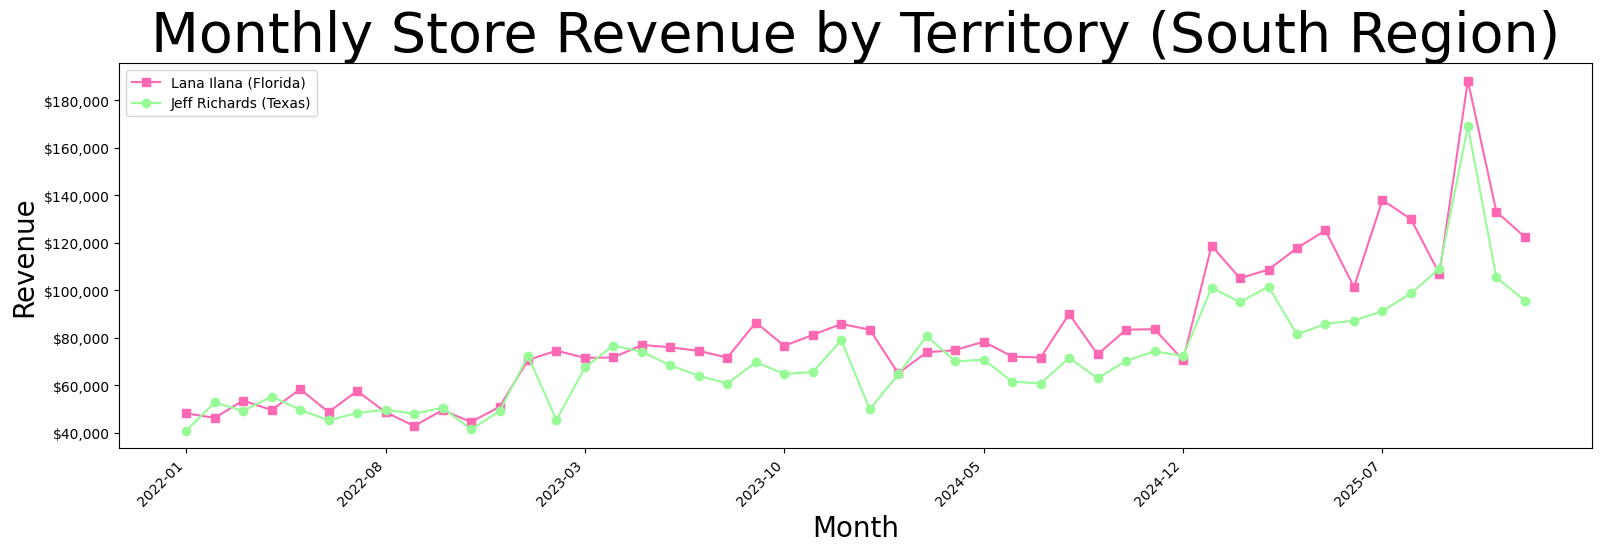

In [ ]:
fig, ax = plt.subplots(figsize=(19,5))

# Convert Period index to strings for plotting
x_labels = monthly_pivot.index.astype(str)
x_pos = range(len(x_labels))

# Plot one line per territory
#Lana Llana
ax.plot(x_pos, monthly_pivot['Lana Ilana'], marker='s', markersize=6, label='Lana Ilana (Florida)', color='hotpink')
#Jeff Richards
ax.plot(x_pos, monthly_pivot['Jeff "Howdy" Richards'], marker='o', markersize=6, label='Jeff Richards (Texas)', color='palegreen')

#condense
ax.set_xticks([i for i in x_pos if i % 7 == 0])
ax.set_xticklabels([x_labels[i] for i in x_pos if i % 7 == 0], rotation=45, ha='right')

#labels
ax.set_title('Monthly Store Revenue by Territory (South Region)', fontsize=40)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('Revenue', fontsize=20)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.show()

### Second chart: Revenue Comparison

A horizontal bar chart works well here because we are comparing a single value (total revenue) across multiple categories (stores). Horizontal bars make the store city names easy to read. We separate the two territories with color.

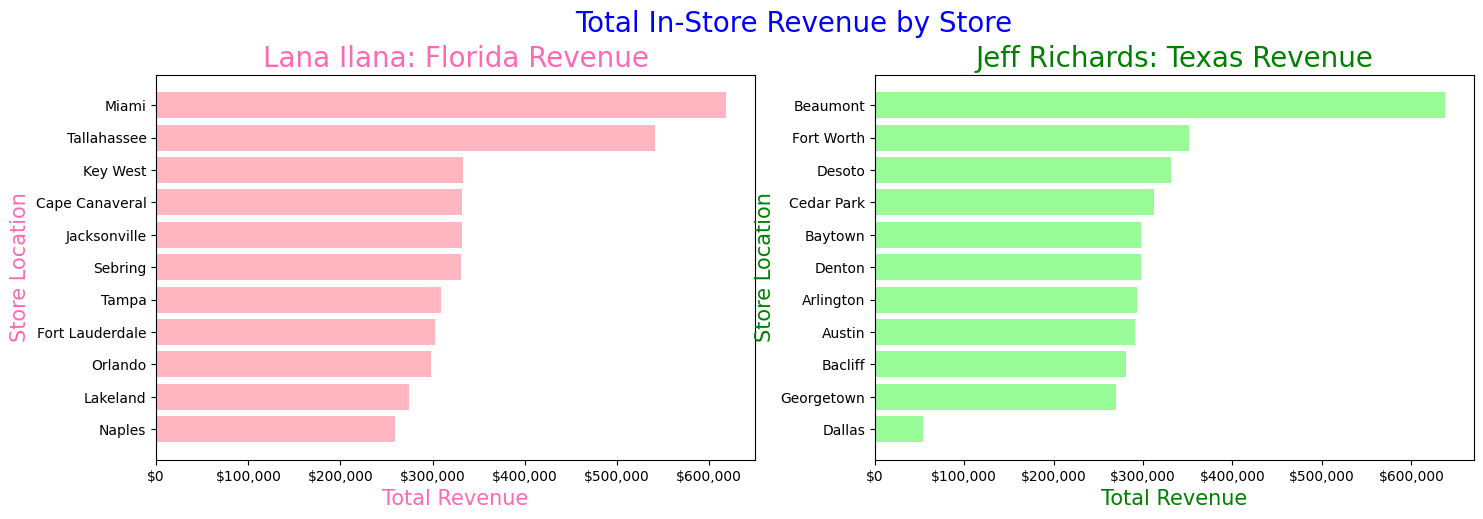

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))


# Lana Ilana
lana_sorted = lana_stores.sort_values('Total Revenue')
axes[0].barh(lana_sorted['Store Location'], lana_sorted['Total Revenue'], color='lightpink')
axes[0].set_title('Lana Ilana: Florida Revenue', fontsize=20, color='hotpink')
axes[0].set_xlabel('Total Revenue', fontsize=15, color='hotpink')
axes[0].set_ylabel('Store Location', fontsize=15, color='hotpink')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Jeff Richards
jeff_sorted = jeff_stores.sort_values('Total Revenue')
axes[1].barh(jeff_sorted['Store Location'], jeff_sorted['Total Revenue'], color='palegreen')
axes[1].set_title('Jeff Richards: Texas Revenue', fontsize=20, color='green')
axes[1].set_xlabel('Total Revenue', fontsize=15, color='green')
axes[1].set_ylabel('Store Location', fontsize=15, color='green')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Total In-Store Revenue by Store', fontsize=20, y=1.01, color='blue')
plt.show()

### Chart 3 — Revenue by Product Category

A **grouped bar chart** is the right choice here because we want to **compare categories across two territories** side by side. Each category gets two bars — one per territory — so we can immediately see where each territory is stronger or weaker.

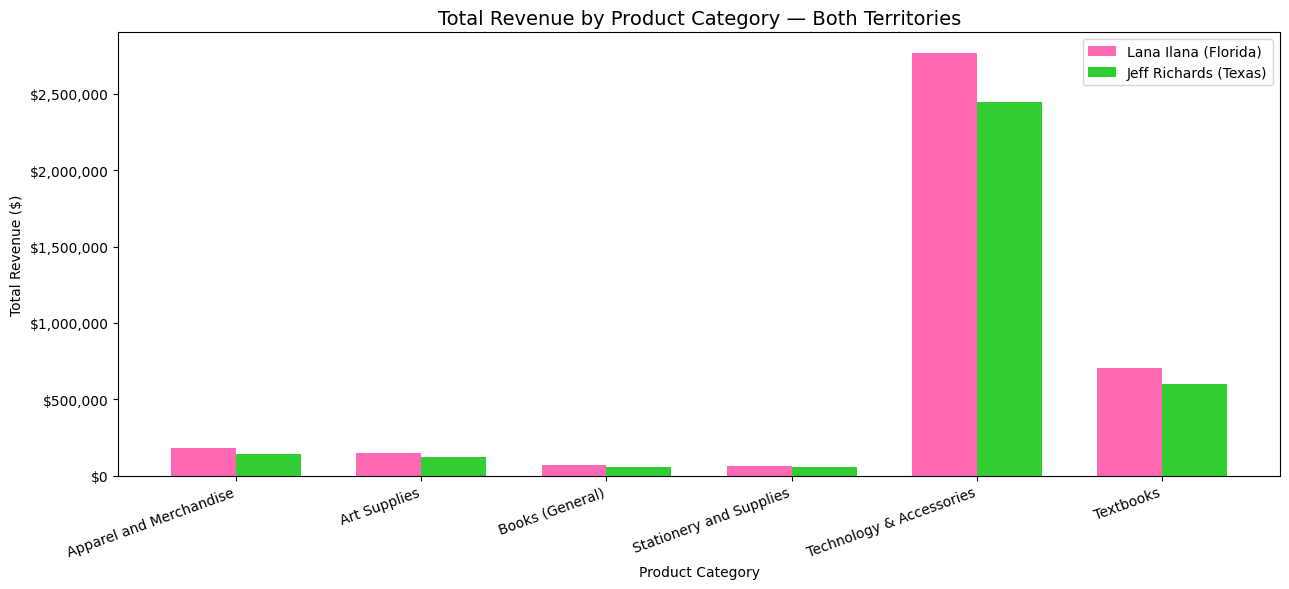

In [ ]:
import numpy as np

# Pivot so each territory is a column
cat_pivot = cat_summary.pivot(index='Category', columns='Territory Manager', values='total_revenue').fillna(0)
cat_pivot.columns.name = None

categories = cat_pivot.index.tolist()
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, cat_pivot['Lana Ilana'], width, label='Lana Ilana (Florida)', color='hotpink')
bars2 = ax.bar(x + width/2, cat_pivot['Jeff "Howdy" Richards'], width, label='Jeff Richards (Texas)', color='limegreen')

ax.set_title('Total Revenue by Product Category', fontsize=14)
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue ($)')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=20, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'${val:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### What This Tells Us: Popular Products and Growth Opportunities

The category data reveals a clear and consistent pattern across **both** territories:

**Technology & Accessories dominates revenue in both territories.**  
It accounts for roughly 70% of total revenue in both Florida (~$2.76M, 70.3%) and Texas (~$2.45M, 71.5%), despite not having the most transactions. This is because the average Technology transaction is ~$466 — by far the highest of any category. Customers are buying high-ticket items like tablets, laptops, and calculators. This category is clearly the engine of the business.

**Textbooks are the second-largest revenue driver.**  
At ~$174 average transaction value, Textbooks bring in meaningful revenue (Florida: $706K, Texas: $597K) with a moderate number of transactions. This is expected for a student-focused bookstore, but it also means revenue here is likely seasonal — concentrated around the start of semesters.

**Stationery & Supplies has the most transactions but the lowest revenue.**  
This is the most striking finding. Stationery has the highest transaction count of any category in both territories (Florida: 6,128 transactions, Texas: 5,396), yet generates the least revenue of all six categories — only about $61K and $54K respectively. The average transaction is less than $10. Customers are coming in frequently to buy low-cost items like pens and notebooks. This is a foot-traffic opportunity: these customers are already in the store, but they are not being upsold into higher-value products.

**Books (General) underperforms for a bookstore.**  
Books (General) has both the fewest transactions and second-lowest revenue. For a business called a *bookstore*, this is a gap worth noting. It suggests that non-textbook books are not a draw — customers may not think of EmporiUm as a destination for general reading.

**The two territories are remarkably similar across all categories.**  
Every category follows the same rank order in both Florida and Texas, and the revenue proportions are nearly identical. This tells us the patterns we're seeing are not territory-specific quirks — they reflect the overall product mix and customer behavior across the EmporiUm brand in the South region.

##Marketing Recommendation for Next Quarter

Based on the analysis above, here is my recommendation for where marketing should focus in the next quarter.

In [ ]:
# Supporting numbers for the recommendation

# Total revenue per territory
territory_totals = our_sales.groupby('Territory Manager')['Sale Amount'].sum()
print('Total Revenue by Territory:')
print(territory_totals.apply(lambda x: f'${x:,.2f}'))
print()

# Lowest-revenue stores in each territory (potential growth targets)
print('Lowest-revenue stores (growth opportunities):')
print(store_revenue.sort_values('Total Revenue').groupby('Territory Manager').head(3)[
    ['Territory Manager', 'Store Location', 'Total Revenue']
].to_string(index=False))
print()

# Category with lowest revenue relative to transaction count (underperforming)
cat_summary['avg_transaction'] = cat_summary['total_revenue'] / cat_summary['total_transactions']
print('Average transaction value by category:')
print(cat_summary[cat_summary['Territory Manager'] == 'Lana Ilana'][['Category','total_transactions','total_revenue','avg_transaction']].sort_values('total_revenue').to_string(index=False))

Total Revenue by Territory:
Territory Manager
Jeff "Howdy" Richards    $3,417,850.01
Lana Ilana               $3,930,187.55
Name: Sale Amount, dtype: object

Lowest-revenue stores (growth opportunities):
    Territory Manager Store Location  Total Revenue
Jeff "Howdy" Richards         Dallas       54444.05
           Lana Ilana         Naples      259602.83
Jeff "Howdy" Richards     Georgetown      269344.64
           Lana Ilana       Lakeland      273835.24
Jeff "Howdy" Richards        Bacliff      280714.34
           Lana Ilana        Orlando      297891.71

Average transaction value by category:
                Category  total_transactions  total_revenue  avg_transaction
 Stationery and Supplies                6128       61114.75         9.973034
         Books (General)                2366       70124.49        29.638415
            Art Supplies                4596      147371.61        32.065189
 Apparel and Merchandise                5539      180626.02        32.609861
       

### Recommendation

Based on the full analysis, my marketing recommendation for next quarter focuses on two areas:

**1. Boost underperforming stores in both territories.**  
In Lana Ilana's Florida territory, stores like Naples and Key West show significantly lower revenue than top performers like Miami and Tallahassee. In Jeff Richards' Texas territory, similar gaps exist between the top store (Bacliff/Beaumont) and the lowest performers. Marketing should run targeted local campaigns — promotions, events, or loyalty incentives — specifically at these lower-performing locations to bring them closer to territory averages.

**2. Grow the Books and Stationery categories.**  
The category analysis shows that Books (General) and Stationery & Supplies consistently generate the fewest transactions and lowest revenue, despite being core products for a student-focused bookstore. These categories represent the biggest opportunity for growth because they are directly aligned with the store's identity and customer base. A targeted promotion — such as a back-to-school bundle, a textbook trade-in program, or a stationery rewards bonus — could meaningfully increase transactions in these categories.

Technology & Accessories is already the strongest category in both territories and does not need additional marketing investment at this time. Art Supplies also performs well, especially in Florida. Marketing resources are best redirected toward the categories and stores with the most room to grow.